# Introduction to Digital Images and Basic Image Processing Using Python

This practical covers the fundamentals of handling images in Python, focusing on libraries like OpenCV and Matplotlib which are essential for Machine Learning workflows.

### Task 1: Import Libraries and Load/Display an Image
We will use `cv2` for image processing and `matplotlib` for visualization. Note that OpenCV reads images in BGR format, so we must convert to RGB for correct display.

Please upload an image file (e.g., .jpg, .png):


Saving 133892009063602793.jpg to 133892009063602793.jpg


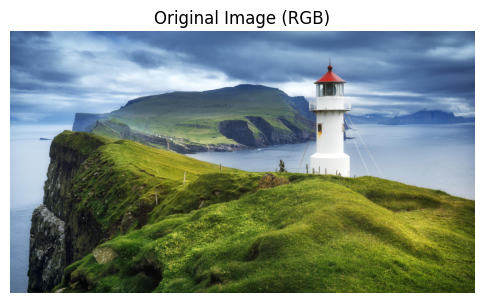

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

# Upload a sample image (e.g., a leaf or flower)
print("Please upload an image file (e.g., .jpg, .png):")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Load the image
img_bgr = cv2.imread(filename)

# Convert BGR to RGB for Matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title('Original Image (RGB)')
plt.axis('off')
plt.show()

### Task 2: Examine Image Properties
Understanding dimensions and data types is crucial for preparing tensors for ML models.

In [2]:
print(f"Image Shape (Height, Width, Channels): {img_rgb.shape}")
print(f"Data Type: {img_rgb.dtype}")

Image Shape (Height, Width, Channels): (2160, 3840, 3)
Data Type: uint8


### Task 3: Inspect Pixel Values
Let's look at the intensity values for the R, G, and B channels at specific coordinates.

In [3]:
coords = [(50, 50), (100, 100), (150, 150)]
for (y, x) in coords:
    pixel_val = img_rgb[y, x]
    print(f"Pixel at (y={y}, x={x}): RGB {pixel_val}")

Pixel at (y=50, x=50): RGB [ 77 113 161]
Pixel at (y=100, x=100): RGB [ 85 121 169]
Pixel at (y=150, x=150): RGB [ 81 118 162]


### Task 4: Grayscale Conversion
**Why use Grayscale?**
Converting to grayscale reduces the computational complexity (from 3 channels to 1) and helps algorithms focus on structural features and shapes rather than color variations, which can be noisy in certain ML tasks like edge detection.

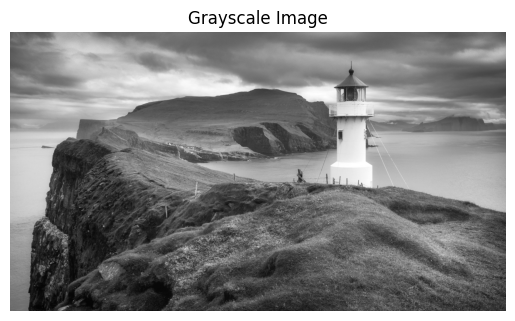

In [4]:
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

plt.imshow(img_gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()

### Task 5: Resize the Image
**Why Standardize?**
Neural networks (like CNNs) require a fixed input size because the number of parameters in fully connected layers is determined by the input dimensions. $224 \times 224$ is a common standard for models like VGG or ResNet.

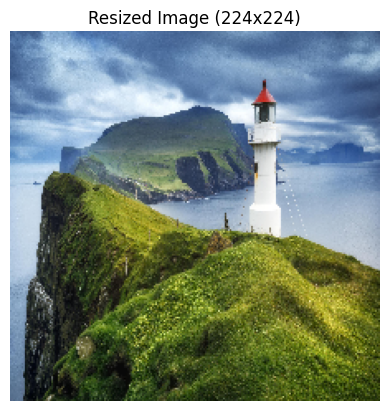

In [5]:
img_resized = cv2.resize(img_rgb, (224, 224))

plt.imshow(img_resized)
plt.title('Resized Image (224x224)')
plt.axis('off')
plt.show()

### Task 6: Crop an Image
**Why Crop?**
Cropping allows the model to focus on the Region of Interest (ROI), removing irrelevant background noise (like soil or hands in a leaf photo) that could confuse the classifier.

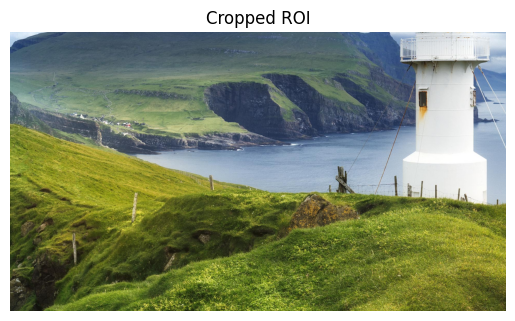

In [6]:
# Example crop: taking a center-ish portion
h, w, _ = img_rgb.shape
img_cropped = img_rgb[h//4:3*h//4, w//4:3*w//4]

plt.imshow(img_cropped)
plt.title('Cropped ROI')
plt.axis('off')
plt.show()

### Task 7: Compare Original and Processed Images

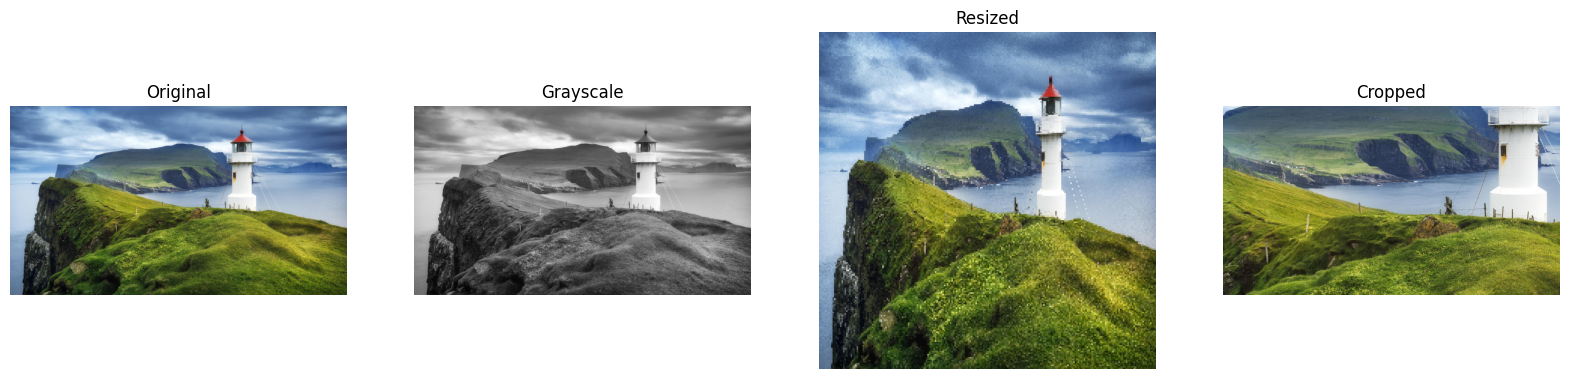

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
titles = ['Original', 'Grayscale', 'Resized', 'Cropped']
images = [img_rgb, img_gray, img_resized, img_cropped]

for ax, img, title in zip(axes, images, titles):
    if title == 'Grayscale':
        ax.imshow(img, cmap='gray')
    else:
        ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')
plt.show()

### Task 8: Save Processed Images

In [8]:
cv2.imwrite('leaf_gray.jpg', img_gray)
# Note: Convert back to BGR for imwrite if using RGB arrays
cv2.imwrite('leaf_resized.jpg', cv2.cvtColor(img_resized, cv2.COLOR_RGB2BGR))
cv2.imwrite('leaf_cropped.jpg', cv2.cvtColor(img_cropped, cv2.COLOR_RGB2BGR))
print("Images saved successfully to the environment.")

Images saved successfully to the environment.


### Task 9: Case Study Question

**Scenario:** Classifying leaf images as Healthy or Diseased from mobile phone photos.

**Proposed Preprocessing Operations:**

1.  **Cropping (ROI Extraction):** Mobile photos often contain background elements (soil, sky, or the user's hand). Cropping ensures the model focuses strictly on the leaf texture and color patterns, preventing the model from learning features from the background (overfitting).
2.  **Resizing (Standardization):** Since mobile phones have varying resolutions (e.g., 12MP vs 48MP), resizing to a uniform dimension (like $224 \times 224$) is mandatory for the input layer of the Convolutional Neural Network (CNN).
3.  **Normalization (Optional but Recommended):** While not explicitly coded above, scaling pixel values (0-255) to a range of (0-1) helps the ML model converge faster during training.
4.  **Color Space Preservation:** Unlike general shape detection, for disease classification, **color information is vital** (to see yellow spots or brown decay). Therefore, I would *not* convert to grayscale but would maintain the RGB channels after standardizing the size and focus.